In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

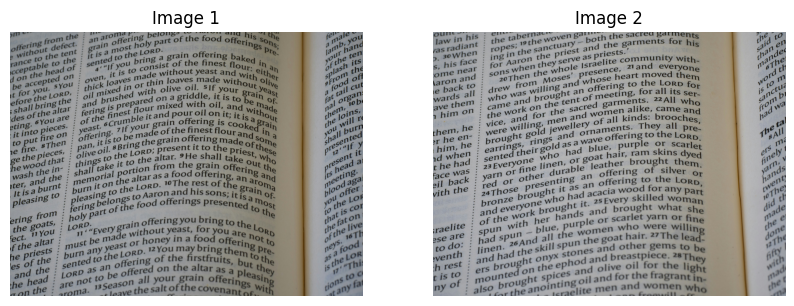

In [3]:
img1 = cv2.imread("images/image1.jpg")
img2 = cv2.imread("images/image2.jpg")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Image 1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Image 2")
plt.axis("off")

plt.show()

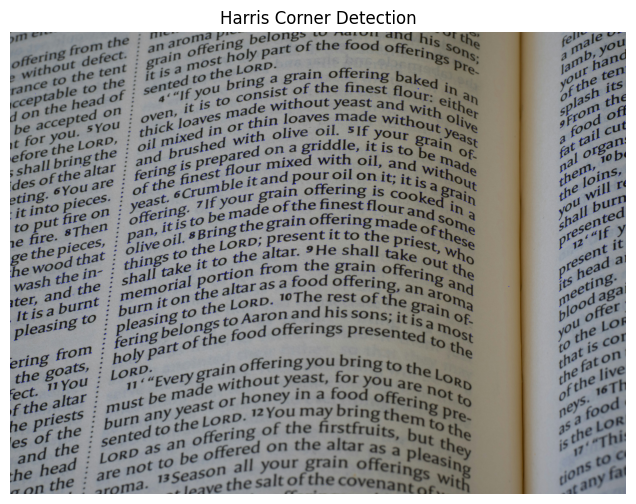

In [4]:
# Convert to float32
gray = np.float32(gray1)

# Harris Corner Detection
corners = cv2.cornerHarris(gray, 2, 3, 0.04)

# Dilate corners to make them visible
corners = cv2.dilate(corners, None)

# Copy image for drawing
harris_img = img1.copy()

# Mark detected corners in red
harris_img[corners > 0.01 * corners.max()] = [255, 0, 0]

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(harris_img, cv2.COLOR_BGR2RGB))
plt.title("Harris Corner Detection")
plt.axis("off")
plt.show()

In [5]:
orb = cv2.ORB_create()

keypoints, descriptors = orb.detectAndCompute(gray1, None)

print("Number of Keypoints:", len(keypoints))

Number of Keypoints: 500


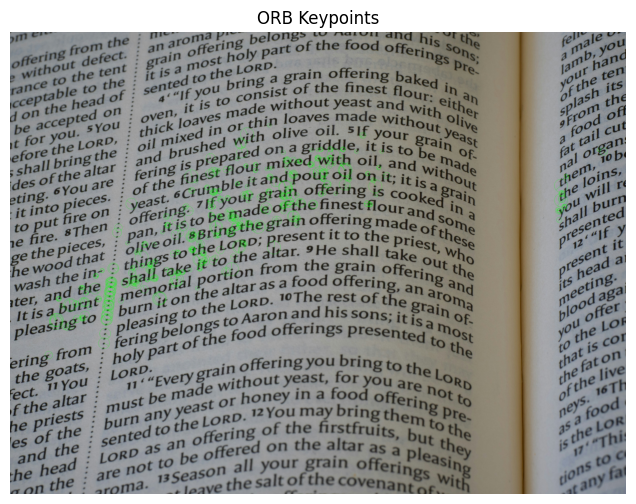

In [6]:
orb_image = cv2.drawKeypoints(
    img1,
    keypoints,
    None,
    color=(0,255,0),
    flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(orb_image, cv2.COLOR_BGR2RGB))
plt.title("ORB Keypoints")
plt.axis("off")
plt.show()

In [7]:
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

print("Total Matches:", len(matches))

Total Matches: 145


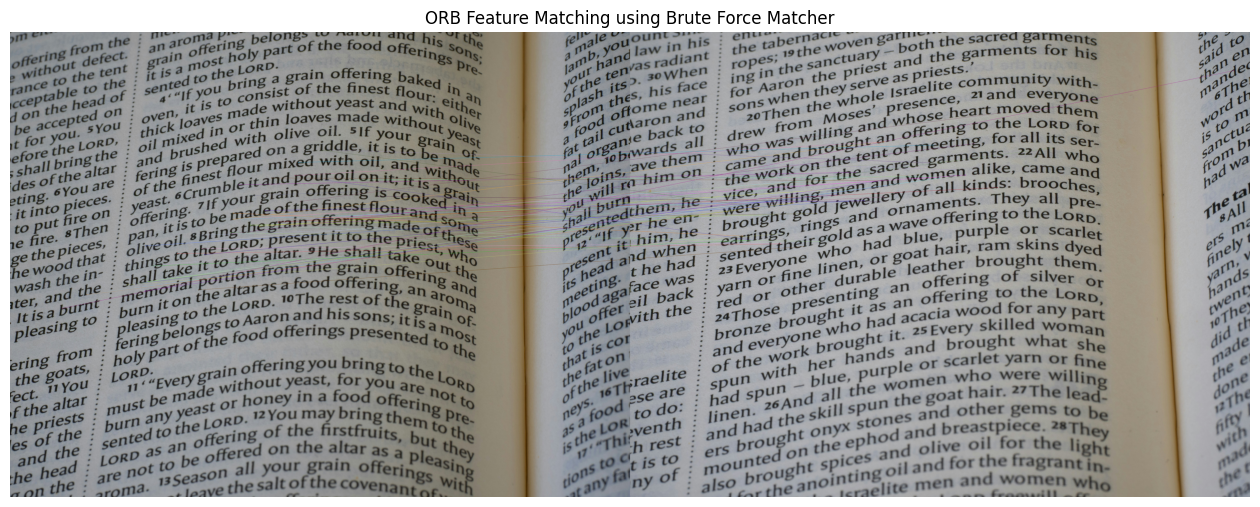

In [8]:
matched_img = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    matches[:50],
    None,
    flags=2
)

plt.figure(figsize=(16,8))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.title("ORB Feature Matching using Brute Force Matcher")
plt.axis("off")
plt.show()

In [9]:
print("Comparison of Harris Corner Detection and ORB\n")

print("1. Harris Corner Detection")
print("- Detects only corners.")
print("- Faster than ORB.")
print("- Does not generate descriptors.")
print("- Cannot match features between images.")
print("- Sensitive to image scaling.\n")

print("2. ORB")
print("- Detects keypoints.")
print("- Generates descriptors.")
print("- Can match features between images.")
print("- Fast and suitable for real-time applications.")
print("- Rotation invariant.")

Comparison of Harris Corner Detection and ORB

1. Harris Corner Detection
- Detects only corners.
- Faster than ORB.
- Does not generate descriptors.
- Cannot match features between images.
- Sensitive to image scaling.

2. ORB
- Detects keypoints.
- Generates descriptors.
- Can match features between images.
- Fast and suitable for real-time applications.
- Rotation invariant.
